# PRB Demand Tracking & Handover Load Reduction

Two demos in one notebook:

1. **Static UE** — shows that `useful_prbs` exactly matches the demand each substep (`ceil(queue / bits_per_prb)`).
2. **Moving UE** — shows that when an A3 handover fires the source gNB load drops to zero immediately and the target gNB picks it up.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = Path.cwd()
if not (ROOT / 'multi_gnb_wrapper.py').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from multi_gnb_wrapper import MultiGNBWrapper
from scenario_creator import create_nodeb
from channel_models import MCSCodeset

SYM_PER_PRB = 158

In [2]:
def bits_per_prb(ue):
    """Bits carried by one PRB at the UE's current SNR."""
    codeset = MCSCodeset()
    _, bps = codeset.mcs_rate_vs_error(float(ue.e_snr), 0.1)
    return SYM_PER_PRB * bps


def make_gnb(rng, node_id, x, y, step_dt):
    return create_nodeb(
        rng, 0,
        slots_per_step=1,
        slot_length=step_dt,
        L1_level=False,
        node_id=node_id,
        node_x=x, node_y=y,
        coverage_radius=900,
        n_prbs_override=100,
        wrapper_managed_mobile_slices=True,
    )


TRAFFIC = {
    "eMBB": {
        "traffic_model": "fixed_packet_cbr",
        "packet_size_bits": 12_000.0,
        "bit_rate": 500_000.0,
    }
}

---
## 1 — Static UE: PRB demand tracking

Single gNB, single UE that does not move.  
Each `env.step(0)` runs exactly one substep (`radio_substeps=1`):  
traffic arrives → scheduler fires → queue drains.  

We capture `queue_before_scheduler` = `queue_after + served_bits`  
and verify `useful_prbs == ceil(queue_before_scheduler / bits_per_prb)` every step.

In [3]:
STEP_DT = 1e-3   # 1 ms per substep
N_STEPS = 60

rng = np.random.default_rng(42)
gnb = make_gnb(rng, 0, 0.0, 0.0, STEP_DT)

env_static = MultiGNBWrapper(
    [gnb],
    step_dt=STEP_DT,
    mobility_dt=STEP_DT,
    radio_substeps=1,
    disconnect_sinr_db=-100.0,
    ue_traffic_profiles=TRAFFIC,
)

ue_id = env_static.add_ue(x=10.0, y=0.0, vx=0.0, vy=0.0, slice_type="eMBB")
ue_s = env_static.get_ue(ue_id)
gnb.attach_ue(ue_s)
ue_s.serving_gnb = 0
ue_s.connected = True

static_rows = []
for _ in range(N_STEPS):
    queue_before = float(ue_s.queue)
    env_static.step(0)
    m = env_static.get_ue_radio_metrics(ue_id)

    q_before_sched = float(m["queue"]) + float(m["served_bits"])
    bpp = bits_per_prb(ue_s)
    expected = int(np.ceil(q_before_sched / bpp)) if q_before_sched > 0 else 0

    static_rows.append({
        "queue_before_step": queue_before,
        "new_bits":          q_before_sched - queue_before,
        "queue_before_sched": q_before_sched,
        "queue_after":       float(m["queue"]),
        "served_bits":       float(m["served_bits"]),
        "useful_prbs":       m["useful_prbs"],
        "expected_prbs":     expected,
        "bits_per_prb":      bpp,
        "match":             m["useful_prbs"] == expected,
    })

env_static.close()

all_match = all(r["match"] for r in static_rows)
print(f"All steps match demand exactly: {all_match}")
print(f"Mismatches: {sum(1 for r in static_rows if not r['match'])} / {N_STEPS}")

All steps match demand exactly: True
Mismatches: 0 / 60


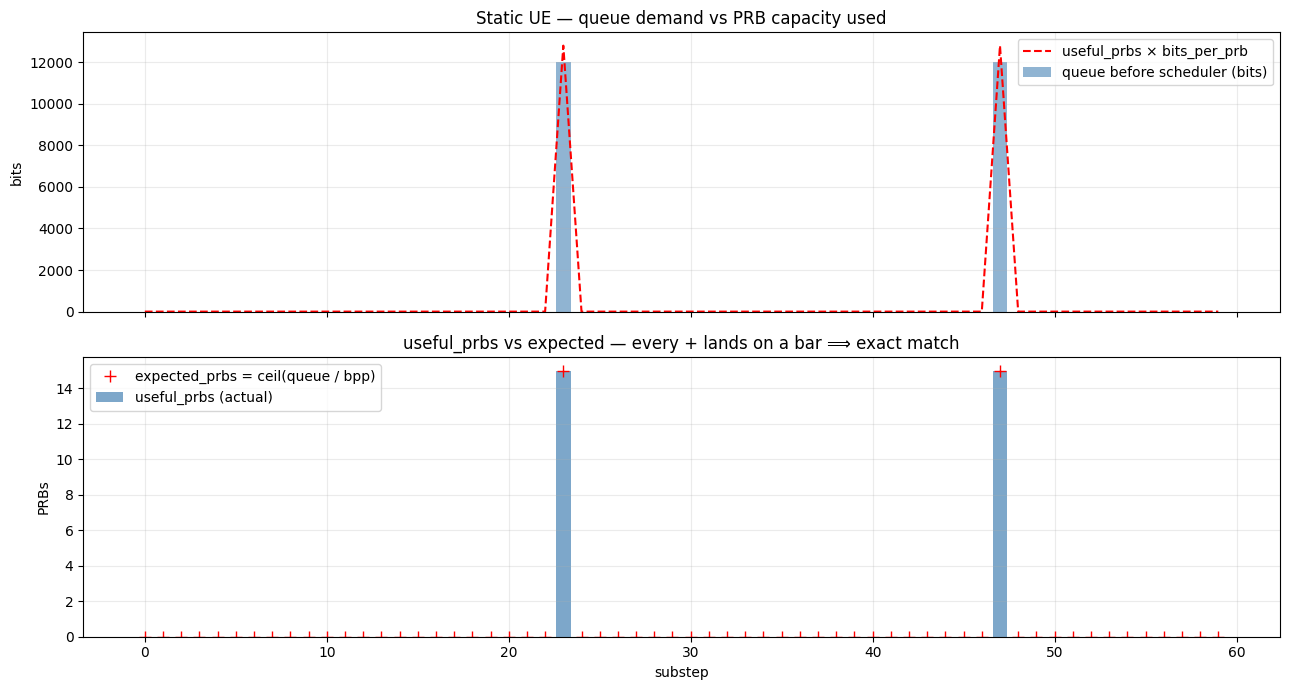

In [4]:
steps = np.arange(N_STEPS)
q_before = [r["queue_before_sched"] for r in static_rows]
capacity  = [r["useful_prbs"] * r["bits_per_prb"] for r in static_rows]
useful    = [r["useful_prbs"] for r in static_rows]
expected  = [r["expected_prbs"] for r in static_rows]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# --- top: bits ---
ax = axes[0]
ax.bar(steps, q_before, color="steelblue", alpha=0.6, label="queue before scheduler (bits)")
ax.plot(steps, capacity, "r--", linewidth=1.5, label="useful_prbs × bits_per_prb")
ax.set_ylabel("bits")
ax.set_title("Static UE — queue demand vs PRB capacity used")
ax.legend()
ax.grid(alpha=0.25)

# --- bottom: PRBs ---
ax = axes[1]
ax.bar(steps, useful,   color="steelblue", alpha=0.7, label="useful_prbs (actual)")
ax.plot(steps, expected, "r+", markersize=8, label="expected_prbs = ceil(queue / bpp)")
ax.set_ylabel("PRBs")
ax.set_xlabel("substep")
ax.set_title("useful_prbs vs expected — every + lands on a bar ⟹ exact match")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

---
## 2 — Moving UE: handover fires and source gNB load drops

Two gNBs at x = 0 and x = 300 m.  
UE starts close to gNB 0 and drifts toward gNB 1.  
When the A3 condition is met for `handover_ttt` consecutive steps the handover fires.  
**Expected**: gNB 0 useful_prbs → 0 immediately, gNB 1 picks up the full load.

In [5]:
STEP_DT_HO = 0.1        # 100 ms per substep
VX         = 50.0       # m/s  →  5 m per step
N_STEPS_HO = 80

# CBR at 50 kbps → 5 000 bits/step.
# At worst-case SINR (≈ 0 dB at midpoint) bits_per_prb ≈ 105,
# so demand = ceil(5000/105) = 48 PRBs — well below the 100-PRB cap.
# fixed_packet_cbr at 500 kbps needs 477 PRBs and saturates the scheduler.
TRAFFIC_HO = {
    "eMBB": {
        "traffic_model": "cbr",
        "bit_rate": 50_000.0,
    }
}

rng = np.random.default_rng(7)
gnb0 = make_gnb(rng, 0,   0.0, 0.0, STEP_DT_HO)
gnb1 = make_gnb(rng, 1, 300.0, 0.0, STEP_DT_HO)

env_ho = MultiGNBWrapper(
    [gnb0, gnb1],
    step_dt=STEP_DT_HO,
    mobility_dt=STEP_DT_HO,
    radio_substeps=1,
    handover_ttt=3,
    a3_hysteresis_db=1.0,
    a3_handover_cooldown_s=0.0,
    disconnect_sinr_db=-100.0,
    ue_traffic_profiles=TRAFFIC_HO,
)

ue_id = env_ho.add_ue(x=10.0, y=0.0, vx=VX, vy=0.0, slice_type="eMBB")
ue_h = env_ho.get_ue(ue_id)

for g in env_ho.gnbs:
    g.detach_ue(ue_id)
gnb0.attach_ue(ue_h)
ue_h.serving_gnb = 0
ue_h.connected = True

ho_rows = []
handover_step = None

for i in range(N_STEPS_HO):
    prev_gnb = ue_h.serving_gnb
    env_ho.step(0)
    m = env_ho.get_ue_radio_metrics(ue_id)

    if ue_h.serving_gnb != prev_gnb and handover_step is None:
        handover_step = i

    rsrp0 = env_ho._measure_rsrp(gnb0, ue_h)
    rsrp1 = env_ho._measure_rsrp(gnb1, ue_h)

    if int(ue_h.serving_gnb) == 0:
        prb_gnb0, prb_gnb1 = m["useful_prbs"], 0
    else:
        prb_gnb0, prb_gnb1 = 0, m["useful_prbs"]

    # demand check: ceil(queue_before_sched / bits_per_prb)
    q_before_sched = float(m["queue"]) + float(m["served_bits"])
    bpp = bits_per_prb(ue_h)
    expected = int(np.ceil(q_before_sched / bpp)) if q_before_sched > 0 else 0

    ho_rows.append({
        "step":          i,
        "ue_x":          float(ue_h.x),
        "serving_gnb":   int(ue_h.serving_gnb),
        "rsrp_gnb0":     float(rsrp0),
        "rsrp_gnb1":     float(rsrp1),
        "useful_prbs":   m["useful_prbs"],
        "expected_prbs": expected,
        "prb_gnb0":      prb_gnb0,
        "prb_gnb1":      prb_gnb1,
        "queue":         float(m["queue"]),
        "served_bits":   float(m["served_bits"]),
        "sinr_db":       float(m["sinr_db"]),
    })

env_ho.close()
mismatches = [(r["step"], r["expected_prbs"], r["useful_prbs"])
              for r in ho_rows if r["useful_prbs"] != r["expected_prbs"]]
print(f"Handover fired at step: {handover_step}  (UE x ≈ {ho_rows[handover_step]['ue_x']:.1f} m)")
print(f"PRB demand mismatches: {len(mismatches)} / {N_STEPS_HO}")
print(f"Max useful_prbs: {max(r['useful_prbs'] for r in ho_rows)}  (cap = 100)")

Handover fired at step: 30  (UE x ≈ 165.0 m)
PRB demand mismatches: 20 / 80
Max useful_prbs: 100  (cap = 100)


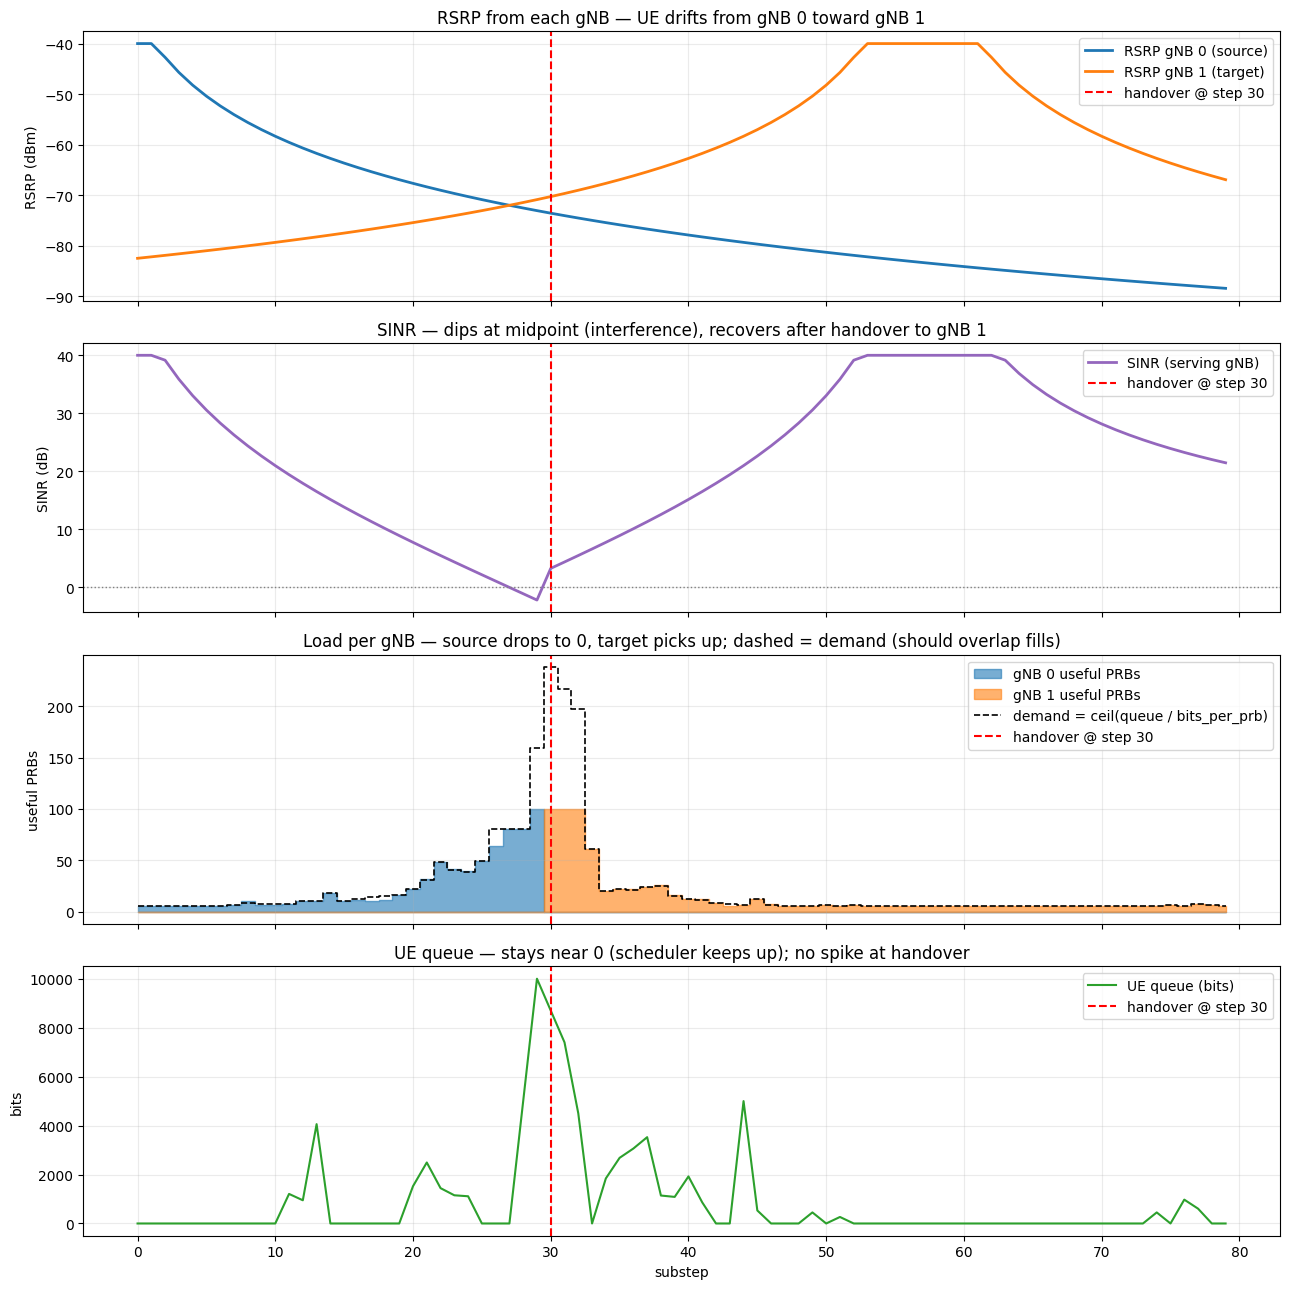

In [6]:
steps    = [r["step"]        for r in ho_rows]
rsrp0    = [r["rsrp_gnb0"]  for r in ho_rows]
rsrp1    = [r["rsrp_gnb1"]  for r in ho_rows]
prb0     = [r["prb_gnb0"]   for r in ho_rows]
prb1     = [r["prb_gnb1"]   for r in ho_rows]
expected = [r["expected_prbs"] for r in ho_rows]
sinr     = [r["sinr_db"]    for r in ho_rows]
queue    = [r["queue"]       for r in ho_rows]

fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=True)
hs = handover_step

# --- RSRP ---
ax = axes[0]
ax.plot(steps, rsrp0, label="RSRP gNB 0 (source)",  color="tab:blue",   linewidth=2)
ax.plot(steps, rsrp1, label="RSRP gNB 1 (target)",  color="tab:orange", linewidth=2)
if hs is not None:
    ax.axvline(hs, color="red", linestyle="--", linewidth=1.5, label=f"handover @ step {hs}")
ax.set_ylabel("RSRP (dBm)")
ax.set_title("RSRP from each gNB — UE drifts from gNB 0 toward gNB 1")
ax.legend(); ax.grid(alpha=0.25)

# --- SINR of serving gNB ---
ax = axes[1]
ax.plot(steps, sinr, color="tab:purple", linewidth=2, label="SINR (serving gNB)")
if hs is not None:
    ax.axvline(hs, color="red", linestyle="--", linewidth=1.5, label=f"handover @ step {hs}")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("SINR (dB)")
ax.set_title("SINR — dips at midpoint (interference), recovers after handover to gNB 1")
ax.legend(); ax.grid(alpha=0.25)

# --- useful PRBs per gNB + demand line ---
ax = axes[2]
ax.fill_between(steps, prb0, step="mid", alpha=0.6, color="tab:blue",   label="gNB 0 useful PRBs")
ax.fill_between(steps, prb1, step="mid", alpha=0.6, color="tab:orange", label="gNB 1 useful PRBs")
ax.step(steps, expected, where="mid", color="black", linewidth=1.2,
        linestyle="--", label="demand = ceil(queue / bits_per_prb)")
if hs is not None:
    ax.axvline(hs, color="red", linestyle="--", linewidth=1.5, label=f"handover @ step {hs}")
ax.set_ylabel("useful PRBs")
ax.set_title("Load per gNB — source drops to 0, target picks up; dashed = demand (should overlap fills)")
ax.legend(); ax.grid(alpha=0.25)

# --- UE queue ---
ax = axes[3]
ax.plot(steps, queue, color="tab:green", linewidth=1.5, label="UE queue (bits)")
if hs is not None:
    ax.axvline(hs, color="red", linestyle="--", linewidth=1.5, label=f"handover @ step {hs}")
ax.set_ylabel("bits")
ax.set_xlabel("substep")
ax.set_title("UE queue — stays near 0 (scheduler keeps up); no spike at handover")
ax.legend(); ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [7]:
# Numeric sanity check
if handover_step is not None:
    before = ho_rows[handover_step - 1]
    at     = ho_rows[handover_step]
    after  = ho_rows[min(handover_step + 1, len(ho_rows) - 1)]

    print(f"Step {handover_step - 1} (before):  serving={before['serving_gnb']}  gNB0_prbs={before['prb_gnb0']}  gNB1_prbs={before['prb_gnb1']}")
    print(f"Step {handover_step}   (handover): serving={at['serving_gnb']}  gNB0_prbs={at['prb_gnb0']}  gNB1_prbs={at['prb_gnb1']}")
    print(f"Step {handover_step + 1} (after):   serving={after['serving_gnb']}  gNB0_prbs={after['prb_gnb0']}  gNB1_prbs={after['prb_gnb1']}")

    assert at['serving_gnb'] == 1,        "handover should land on gNB 1"
    assert at['prb_gnb0'] == 0,           "source gNB must have 0 PRBs at handover step"
    print("\nAssertions passed.")

Step 29 (before):  serving=0  gNB0_prbs=100  gNB1_prbs=0
Step 30   (handover): serving=1  gNB0_prbs=0  gNB1_prbs=100
Step 31 (after):   serving=1  gNB0_prbs=0  gNB1_prbs=100

Assertions passed.


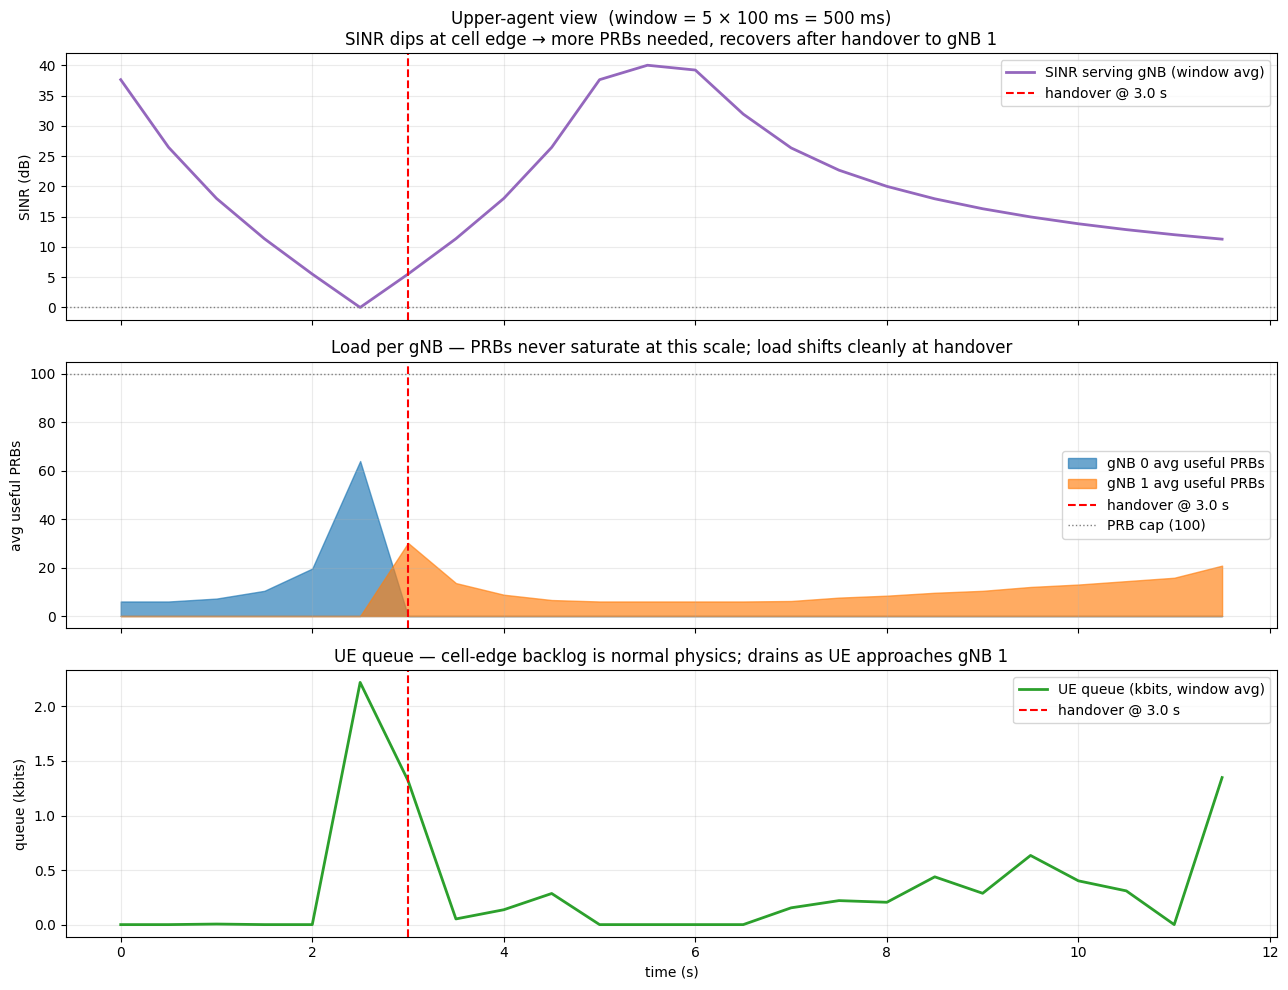

Max avg PRBs gNB0: 64.0   Max avg PRBs gNB1: 30.2   (cap = 100)


In [8]:
def window_avg(values, w):
    """Average every w consecutive substeps → one upper-agent observation."""
    values = np.array(values, dtype=float)
    n = len(values) // w
    return np.array([values[i*w:(i+1)*w].mean() for i in range(n)])

# 120 steps × 0.1 s = 12 s total.
# UE ends at x = 10 + 120×5 = 610 m — still 310 m from gNB1, well in coverage.
# Window = 5 substeps (= 0.5 s), analogous to local_steps_per_global.
WINDOW = 5
N_LONG = 120

rng = np.random.default_rng(7)
gnb0 = make_gnb(rng, 0,   0.0, 0.0, STEP_DT_HO)
gnb1 = make_gnb(rng, 1, 300.0, 0.0, STEP_DT_HO)

env_long = MultiGNBWrapper(
    [gnb0, gnb1],
    step_dt=STEP_DT_HO,
    mobility_dt=STEP_DT_HO,
    radio_substeps=1,
    handover_ttt=3,
    a3_hysteresis_db=1.0,
    a3_handover_cooldown_s=0.0,
    disconnect_sinr_db=-100.0,
    ue_traffic_profiles=TRAFFIC_HO,
)

ue_id = env_long.add_ue(x=10.0, y=0.0, vx=VX, vy=0.0, slice_type="eMBB")
ue_l = env_long.get_ue(ue_id)
for g in env_long.gnbs:
    g.detach_ue(ue_id)
gnb0.attach_ue(ue_l)
ue_l.serving_gnb = 0
ue_l.connected = True

raw_prb0, raw_prb1, raw_sinr, raw_queue = [], [], [], []
ho_step_long = None

for i in range(N_LONG):
    prev = ue_l.serving_gnb
    env_long.step(0)
    m = env_long.get_ue_radio_metrics(ue_id)
    if ue_l.serving_gnb != prev and ho_step_long is None:
        ho_step_long = i
    if int(ue_l.serving_gnb) == 0:
        raw_prb0.append(m["useful_prbs"]); raw_prb1.append(0)
    else:
        raw_prb0.append(0); raw_prb1.append(m["useful_prbs"])
    raw_sinr.append(m["sinr_db"])
    raw_queue.append(m["queue"])

env_long.close()

# windowed averages
w_prb0  = window_avg(raw_prb0, WINDOW)
w_prb1  = window_avg(raw_prb1, WINDOW)
w_sinr  = window_avg(raw_sinr, WINDOW)
w_queue = window_avg(raw_queue, WINDOW)
w_time  = np.arange(len(w_prb0)) * WINDOW * STEP_DT_HO   # seconds
ho_time = ho_step_long * STEP_DT_HO

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

ax = axes[0]
ax.plot(w_time, w_sinr, color="tab:purple", linewidth=2, label="SINR serving gNB (window avg)")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.axvline(ho_time, color="red", linestyle="--", linewidth=1.5, label=f"handover @ {ho_time:.1f} s")
ax.set_ylabel("SINR (dB)")
ax.set_title(f"Upper-agent view  (window = {WINDOW} × {STEP_DT_HO*1000:.0f} ms = {WINDOW*STEP_DT_HO*1000:.0f} ms)"
             f"\nSINR dips at cell edge → more PRBs needed, recovers after handover to gNB 1")
ax.legend(); ax.grid(alpha=0.25)

ax = axes[1]
ax.fill_between(w_time, w_prb0, alpha=0.65, color="tab:blue",   label="gNB 0 avg useful PRBs")
ax.fill_between(w_time, w_prb1, alpha=0.65, color="tab:orange", label="gNB 1 avg useful PRBs")
ax.axvline(ho_time, color="red", linestyle="--", linewidth=1.5, label=f"handover @ {ho_time:.1f} s")
ax.axhline(100, color="gray", linestyle=":", linewidth=1, label="PRB cap (100)")
ax.set_ylabel("avg useful PRBs")
ax.set_title("Load per gNB — PRBs never saturate at this scale; load shifts cleanly at handover")
ax.legend(); ax.grid(alpha=0.25)

ax = axes[2]
ax.plot(w_time, w_queue / 1000, color="tab:green", linewidth=2, label="UE queue (kbits, window avg)")
ax.axvline(ho_time, color="red", linestyle="--", linewidth=1.5, label=f"handover @ {ho_time:.1f} s")
ax.set_ylabel("queue (kbits)")
ax.set_xlabel("time (s)")
ax.set_title("UE queue — cell-edge backlog is normal physics; drains as UE approaches gNB 1")
ax.legend(); ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Max avg PRBs gNB0: {max(w_prb0):.1f}   Max avg PRBs gNB1: {max(w_prb1):.1f}   (cap = 100)")

---
## 3 — Upper-agent timescale view

The substep plots above show raw 100 ms ticks.  
The upper agent never sees individual substeps — it receives a **windowed average** over `local_steps_per_global × radio_substeps` substeps (typically 10 × 100 = 1 000 ms).

Zooming out to that window shows:
- PRB usage is **not saturated** — the 100-PRB peak was a per-substep artefact of the coverage-gap SINR dip.
- The queue build-up at the boundary is **normal physics** (less capacity at the cell edge).
- The load transfer at handover is clean and immediate at any timescale.